In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')
!ln -s /content/gdrive/My\ Drive/ /mydrive
%cd /mydrive/Pytorch-Models/

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
ln: failed to create symbolic link '/mydrive/My Drive': File exists
/content/gdrive/.shortcut-targets-by-id/1aJsbt04Jz9xcLP_lg7fvP4Bpdce6GQlC/Pytorch-Models


In [ ]:
# STEP 1: Install compatible PyTorch (2.0.1 + CUDA 11.7)
!pip install torch==2.0.1 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu117

# STEP 2: Install OpenMMLab tools
!pip install -U openmim
!mim install "mmengine>=0.7.4"
!mim install "mmcv==2.1.0"

# STEP 3: Clone MMDetection & install
!git clone https://github.com/open-mmlab/mmdetection.git
%cd mmdetection
!pip install -e .

In [ ]:
!pip uninstall mmdet -y

Found existing installation: mmdet 3.3.0
Uninstalling mmdet-3.3.0:
  Successfully uninstalled mmdet-3.3.0


In [ ]:
!pip install -U openmim
!mim install "mmdet>=3.0.0rc6, <3.1.0"

In [ ]:
!pip uninstall mmcv -y

Found existing installation: mmcv 2.1.0
Uninstalling mmcv-2.1.0:
  Successfully uninstalled mmcv-2.1.0


In [ ]:
!mim install "mmcv>=2.0.0rc4, <2.1.0"

In [ ]:
# STEP 4: Final check
!python -c "import torch; import mmcv; import mmdet; print('PyTorch:', torch.__version__); print('MMCV:', mmcv.__version__); print('MMDet:', mmdet.__version__)"

PyTorch: 2.0.1+cu117
MMCV: 2.0.1
MMDet: 3.0.0


In [ ]:
!git clone https://github.com/open-mmlab/mmdeploy.git
%cd mmdeploy
!pip install -e .

In [ ]:
!python -c "import mmdeploy; print('MMDeploy:', mmdeploy.__version__)"

MMDeploy: 1.3.1


In [ ]:
!git clone -b 1.x https://github.com/open-mmlab/mmrotate.git
%cd mmrotate
!pip install -e .

In [ ]:
# Check MMRotate installation
!python -c "import mmrotate; print('MMRotate:', mmrotate.__version__)"

MMRotate: 1.0.0rc1


In [ ]:
!pip install numpy==1.24.4

In [ ]:
!ls mmrotate/configs/rotated_faster_rcnn/

metafile.yml  rotated-faster-rcnn-le90_r50_fpn_1x_dota.py
README.md     rotated-faster-rcnn-markers.py


In [ ]:
from mmdet.apis import init_detector, inference_detector
import mmcv

# Config and checkpoint paths
config_file = 'mmrotate/configs/rotated_faster_rcnn/rotated-faster-rcnn-le90_r50_fpn_1x_dota.py'
checkpoint_file = 'https://download.openmmlab.com/mmrotate/v0.1.0/rotated_faster_rcnn/rotated_faster_rcnn_r50_fpn_1x_dota_le90/rotated_faster_rcnn_r50_fpn_1x_dota_le90-0393aa5c.pth'

# Initialize the model
model = init_detector(config_file, checkpoint_file, device='cuda:0')  # or 'cpu'

# Image path
img = '/content/gdrive/MyDrive/Pytorch-Models/datasets/markerpensseg/valid/1B3246F6-8785-4465-AC56-3BE7AA44003D_jpeg.rf.ddd6b9b6921d9589dfae0019661b06a1.jpg'

# Run inference
result = inference_detector(model, img)

# Access the boxes, scores, and labels
print(result.pred_instances.bboxes)
print(result.pred_instances.scores)
print(result.pred_instances.labels)

Loads checkpoint by http backend from path: https://download.openmmlab.com/mmrotate/v0.1.0/rotated_faster_rcnn/rotated_faster_rcnn_r50_fpn_1x_dota_le90/rotated_faster_rcnn_r50_fpn_1x_dota_le90-0393aa5c.pth
tensor([[ 1.1544e+03,  8.1483e+02,  7.3861e+02,  1.0731e+02, -1.1057e+00],
        [ 1.1501e+03,  8.2993e+02,  7.6156e+02,  1.0813e+02, -1.1000e+00]],
       device='cuda:0')
tensor([0.6345, 0.0544], device='cuda:0')
tensor([ 6, 12], device='cuda:0')


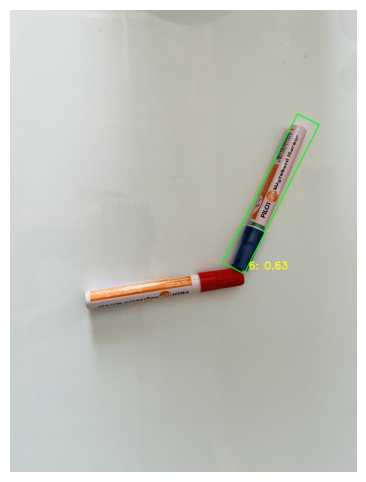

In [ ]:
import cv2
import matplotlib.pyplot as plt
import torch
import numpy as np

def draw_rotated_bbox(img, rotated_bbox, label, score, color=(0, 0, 255), thickness=3):
    # rotated_bbox is [x_ctr, y_ctr, w, h, angle]
    x_ctr, y_ctr, w, h, angle = rotated_bbox

    # Calculate the 4 corners of the rotated box
    # angle is in radians in MMRotate 1.x (le90/oc format)
    rect = ((x_ctr, y_ctr), (w, h), np.degrees(angle))
    box = cv2.boxPoints(rect)
    box = np.intp(box)

    # Draw the rotated box
    cv2.drawContours(img, [box], 0, color, thickness)

    # Put label text near the first corner
    cv2.putText(
        img, f"{label}: {score:.2f}", (int(box[0][0]) + 20, int(box[0][1]) - 20),
        cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 255, 255), 3, cv2.LINE_AA
    )

# Access the prediction results
pred_instances = result.pred_instances.cpu()

CONF_THRESHOLD = 0.3

# Load the image pixels (img variable is the path)
img_data = cv2.imread(img)
img_with_results = img_data.copy()

# Draw boxes and labels
for i in range(len(pred_instances.bboxes)):
    score = pred_instances.scores[i].item()
    if score < CONF_THRESHOLD:
        continue

    # Get Class and Color
    label_id = pred_instances.labels[i].item()
    class_name = str(label_id)
    color = (0, 255, 0)

    # Extract rotated bbox [x_ctr, y_ctr, w, h, angle]
    rotated_bbox = pred_instances.bboxes[i].tolist()

    # Draw Rotated Bounding Box
    draw_rotated_bbox(img_with_results, rotated_bbox, class_name, score, color=color)

# Show result
img_rgb = cv2.cvtColor(img_with_results, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(6, 6))
plt.axis('off')
plt.imshow(img_rgb)
plt.show()

In [ ]:
import os
import json

def count_images(image_dir, exts={".jpg", ".jpeg", ".png", ".bmp", ".webp"}):
    image_count = 0
    for filename in os.listdir(image_dir):
        if os.path.splitext(filename.lower())[1] in exts:
            image_count += 1
    print(f"Total images: {image_count}")

def count_texts(image_dir, exts={".txt"}):
    text_count = 0
    for filename in os.listdir(image_dir):
        if os.path.splitext(filename.lower())[1] in exts:
            text_count += 1
    print(f"Total texts: {text_count}")

count_images("/content/gdrive/MyDrive/Pytorch-Models/datasets/markerpensobb/train/images/")
count_images("/content/gdrive/MyDrive/Pytorch-Models/datasets/markerpensobb/valid/images/")
count_texts("/content/gdrive/MyDrive/Pytorch-Models/datasets/markerpensobb/train/labels/")
count_texts("/content/gdrive/MyDrive/Pytorch-Models/datasets/markerpensobb/valid/labels/")

Total images: 235
Total images: 30
Total texts: 235
Total texts: 30


In [ ]:
count_texts("/content/gdrive/MyDrive/Pytorch-Models/datasets/markerpensobb/train/labelTxt/")
count_texts("/content/gdrive/MyDrive/Pytorch-Models/datasets/markerpensobb/valid/labelTxt/")

Total texts: 235
Total texts: 30


In [ ]:
import os
import cv2

# Settings
# yolo_obb_path = '/content/gdrive/MyDrive/Pytorch-Models/datasets/markerpensobb/train/labels/'
# images_path = '/content/gdrive/MyDrive/Pytorch-Models/datasets/markerpensobb/train/images/'
# dota_out_path = '/content/gdrive/MyDrive/Pytorch-Models/datasets/markerpensobb/train/labelTxt'
yolo_obb_path = '/content/gdrive/MyDrive/Pytorch-Models/datasets/markerpensobb/valid/labels/'
images_path = '/content/gdrive/MyDrive/Pytorch-Models/datasets/markerpensobb/valid/images/'
dota_out_path = '/content/gdrive/MyDrive/Pytorch-Models/datasets/markerpensobb/valid/labelTxt'
os.makedirs(dota_out_path, exist_ok=True)

# class names in order
classes = ["CAP"]

for label_file in os.listdir(yolo_obb_path):
    img_name = label_file.replace('.txt', '.jpg') # or .png
    img = cv2.imread(os.path.join(images_path, img_name))
    h, w, _ = img.shape

    with open(os.path.join(yolo_obb_path, label_file), 'r') as f:
        lines = f.readlines()

    with open(os.path.join(dota_out_path, label_file), 'w') as f_out:
        for line in lines:
            parts = line.split()
            cls_id = int(parts[0])
            coords = [float(x) for x in parts[1:]]

            # 1. Denormalize coordinates (convert 0-1 to actual pixels)
            px_coords = []
            for i in range(0, 8, 2):
                px_coords.append(coords[i] * w)     # x * width
                px_coords.append(coords[i+1] * h)   # y * height

            # 2. Write in DOTA format: x1 y1 x2 y2 x3 y3 x4 y4 class_name 0
            formatted_line = " ".join([f"{c:.2f}" for c in px_coords])
            f_out.write(f"{formatted_line} {classes[cls_id]} 0\n")

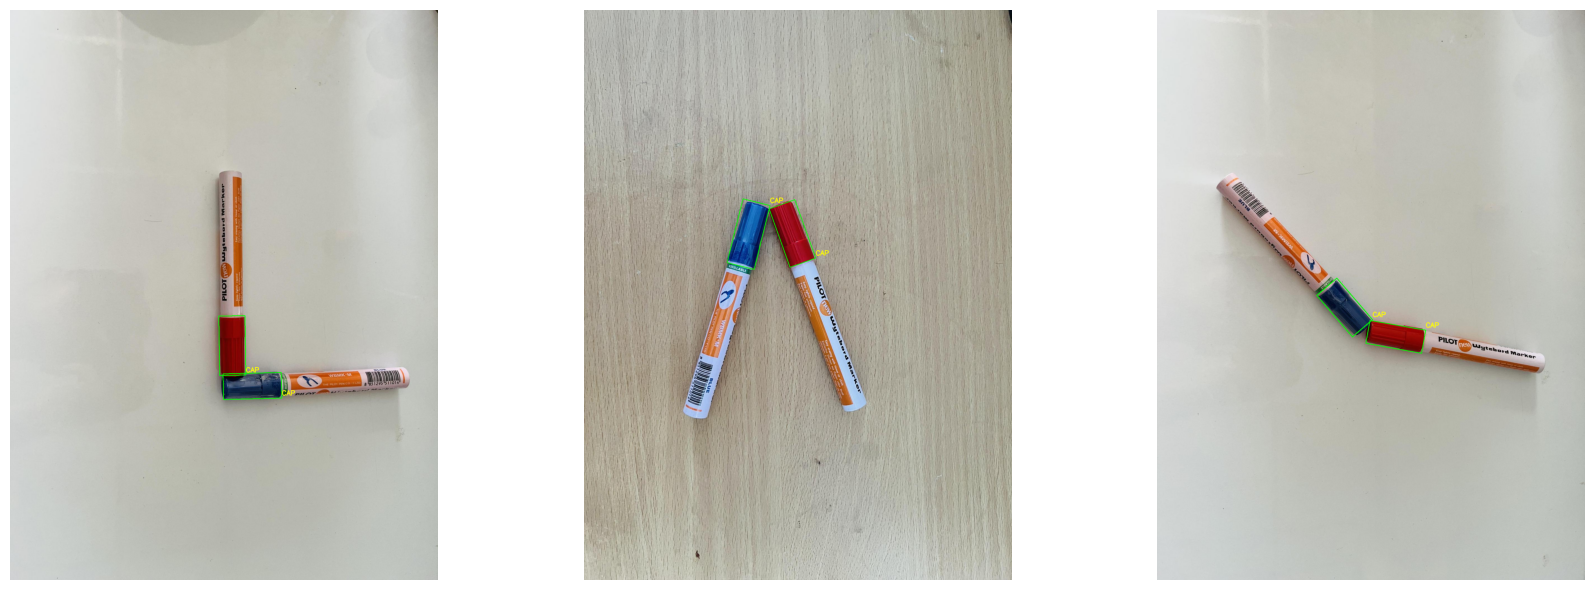

In [ ]:
import cv2
import os
import matplotlib.pyplot as plt
import numpy as np

def debug_dota_visual_grid(img_dir, label_dir, num_samples=3):
    image_files = [f for f in os.listdir(img_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]
    samples = image_files[:num_samples]

    # Create the grid: 1 row, 3 columns
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    for i, img_name in enumerate(samples):
        img_path = os.path.join(img_dir, img_name)
        label_path = os.path.join(label_dir, img_name.rsplit('.', 1)[0] + '.txt')

        img = cv2.imread(img_path)
        if img is None or not os.path.exists(label_path):
            continue

        with open(label_path, 'r') as f:
            for line in f.readlines():
                items = line.strip().split()
                # DOTA: x1 y1 x2 y2 x3 y3 x4 y4 class_name difficulty
                coords = np.array(items[:8], dtype=np.float32).reshape(-1, 2).astype(np.int32)
                class_name = items[8]

                cv2.polylines(img, [coords], isClosed=True, color=(0, 255, 0), thickness=2)
                cv2.putText(img, class_name, (coords[0][0], coords[0][1]-10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 255), 2)

        # Plot in the specific grid column
        ax = axes[i]
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        # ax.set_title(f"Debug: {img_name}", fontsize=10)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# Run on valid set
img_folder = "/content/gdrive/MyDrive/Pytorch-Models/datasets/markerpensobb/valid/images/"
label_folder = "/content/gdrive/MyDrive/Pytorch-Models/datasets/markerpensobb/valid/labelTxt/"
debug_dota_visual_grid(img_folder, label_folder)

In [ ]:
custom_cfg = """
_base_ = 'rotated-faster-rcnn-le90_r50_fpn_1x_dota.py'

# Custom classes
dataset_type = 'DOTADataset'
metainfo = dict(classes=("CAP",))
num_classes = 1

# Paths
data_root = '/content/gdrive/MyDrive/Pytorch-Models/datasets/'
train_ann = data_root + 'markerpensobb/train/labelTxt/'
val_ann = data_root + 'markerpensobb/valid/labelTxt/'
train_img = data_root + 'markerpensobb/train/images/'
val_img = data_root + 'markerpensobb/valid/images/'

# Pipelines
train_pipeline = [
    dict(type='mmdet.LoadImageFromFile'),
    dict(type='mmdet.LoadAnnotations', with_bbox=True, box_type='qbox'),
    dict(type='ConvertBoxType', box_type_mapping=dict(gt_bboxes='rbox')),
    dict(type='mmdet.Resize', scale=(512, 512), keep_ratio=True),
    dict(
        type='mmdet.RandomFlip',
        prob=0.75,
        direction=['horizontal', 'vertical', 'diagonal']),
    dict(type='mmdet.PackDetInputs')
]
val_pipeline = [
    dict(type='mmdet.LoadImageFromFile'),
    dict(type='mmdet.Resize', scale=(512, 512), keep_ratio=True),
    # avoid bboxes being resized
    dict(type='mmdet.LoadAnnotations', with_bbox=True, box_type='qbox'),
    dict(type='ConvertBoxType', box_type_mapping=dict(gt_bboxes='rbox')),
    dict(
        type='mmdet.PackDetInputs',
        meta_keys=('img_id', 'img_path', 'ori_shape', 'img_shape',
                   'scale_factor'))
]

# Data loader
train_dataloader = dict(
    batch_size=8,
    num_workers=2,
    persistent_workers=True,
    sampler=dict(type='DefaultSampler', shuffle=True),
    batch_sampler=None,
    dataset=dict(
        type=dataset_type,
        data_root=data_root,
        ann_file=train_ann,
        data_prefix=dict(img_path=train_img),
        img_suffix='jpg',
        filter_cfg=dict(filter_empty_gt=True),
        metainfo=metainfo,
        pipeline=train_pipeline))
val_dataloader = dict(
    batch_size=8,
    num_workers=2,
    persistent_workers=True,
    drop_last=False,
    sampler=dict(type='DefaultSampler', shuffle=False),
    dataset=dict(
        type=dataset_type,
        data_root=data_root,
        ann_file=val_ann,
        data_prefix=dict(img_path=val_img),
        img_suffix='jpg',
        test_mode=True,
        metainfo=metainfo,
        pipeline=val_pipeline))

test_dataloader = val_dataloader

# Evaluator
val_evaluator = dict(type='DOTAMetric', metric='mAP')
test_evaluator = val_evaluator

# Model
angle_version = 'le90'
model = dict(
    type='mmdet.FasterRCNN',
    data_preprocessor=dict(
        type='mmdet.DetDataPreprocessor',
        mean=[123.675, 116.28, 103.53],
        std=[58.395, 57.12, 57.375],
        bgr_to_rgb=True,
        pad_size_divisor=32,
        boxtype2tensor=False),
    backbone=dict(
        type='mmdet.ResNet',
        depth=50,
        num_stages=4,
        out_indices=(0, 1, 2, 3),
        frozen_stages=1,
        norm_cfg=dict(type='BN', requires_grad=True),
        norm_eval=True,
        style='pytorch',
        init_cfg=dict(type='Pretrained', checkpoint='torchvision://resnet50')),
    neck=dict(
        type='mmdet.FPN',
        in_channels=[256, 512, 1024, 2048],
        out_channels=256,
        num_outs=5),
    rpn_head=dict(
        type='mmdet.RPNHead',
        in_channels=256,
        feat_channels=256,
        anchor_generator=dict(
            type='mmdet.AnchorGenerator',
            scales=[8],
            ratios=[0.5, 1.0, 2.0],
            strides=[4, 8, 16, 32, 64],
            use_box_type=True),
        bbox_coder=dict(
            type='DeltaXYWHHBBoxCoder',
            target_means=[0.0, 0.0, 0.0, 0.0],
            target_stds=[1.0, 1.0, 1.0, 1.0],
            use_box_type=True),
        loss_cls=dict(
            type='mmdet.CrossEntropyLoss', use_sigmoid=True, loss_weight=1.0),
        loss_bbox=dict(
            type='mmdet.SmoothL1Loss',
            beta=0.1111111111111111,
            loss_weight=1.0)),
    roi_head=dict(
        type='mmdet.StandardRoIHead',
        bbox_roi_extractor=dict(
            type='mmdet.SingleRoIExtractor',
            roi_layer=dict(type='RoIAlign', output_size=7, sampling_ratio=0),
            out_channels=256,
            featmap_strides=[4, 8, 16, 32]),
        bbox_head=dict(
            type='mmdet.Shared2FCBBoxHead',
            predict_box_type='rbox',
            in_channels=256,
            fc_out_channels=1024,
            roi_feat_size=7,
            num_classes=num_classes,
            reg_predictor_cfg=dict(type='mmdet.Linear'),
            cls_predictor_cfg=dict(type='mmdet.Linear'),
            bbox_coder=dict(
                type='DeltaXYWHTHBBoxCoder',
                angle_version=angle_version,
                norm_factor=2,
                edge_swap=True,
                target_means=(.0, .0, .0, .0, .0),
                target_stds=(0.1, 0.1, 0.2, 0.2, 0.1)),
            reg_class_agnostic=True,
            loss_cls=dict(
                type='mmdet.CrossEntropyLoss',
                use_sigmoid=False,
                loss_weight=1.0),
            loss_bbox=dict(
                type='mmdet.SmoothL1Loss', beta=1.0, loss_weight=1.0))),
    train_cfg=dict(
        rpn=dict(
            assigner=dict(
                type='mmdet.MaxIoUAssigner',
                pos_iou_thr=0.7,
                neg_iou_thr=0.3,
                min_pos_iou=0.3,
                match_low_quality=True,
                ignore_iof_thr=-1,
                iou_calculator=dict(type='RBbox2HBboxOverlaps2D')),
            sampler=dict(
                type='mmdet.RandomSampler',
                num=256,
                pos_fraction=0.5,
                neg_pos_ub=-1,
                add_gt_as_proposals=False),
            allowed_border=0,
            pos_weight=-1,
            debug=False),
        rpn_proposal=dict(
            nms_pre=2000,
            max_per_img=2000,
            nms=dict(type='nms', iou_threshold=0.7),
            min_bbox_size=0),
        rcnn=dict(
            assigner=dict(
                type='mmdet.MaxIoUAssigner',
                pos_iou_thr=0.5,
                neg_iou_thr=0.5,
                min_pos_iou=0.5,
                match_low_quality=False,
                ignore_iof_thr=-1,
                iou_calculator=dict(type='RBbox2HBboxOverlaps2D')),
            sampler=dict(
                type='mmdet.RandomSampler',
                num=512,
                pos_fraction=0.25,
                neg_pos_ub=-1,
                add_gt_as_proposals=True),
            pos_weight=-1,
            debug=False)),
    test_cfg=dict(
        rpn=dict(
            nms_pre=2000,
            max_per_img=2000,
            nms=dict(type='nms', iou_threshold=0.7),
            min_bbox_size=0),
        rcnn=dict(
            nms_pre=2000,
            min_bbox_size=0,
            score_thr=0.05,
            nms=dict(type='nms_rotated', iou_threshold=0.1),
            max_per_img=2000)))

# Schedule
train_cfg = dict(type='EpochBasedTrainLoop', max_epochs=10, val_interval=1)
val_cfg = dict(type='ValLoop')
test_cfg = dict(type='TestLoop')

# Optimizer
optim_wrapper = dict(
    optimizer=dict(type='SGD', lr=0.005, momentum=0.9, weight_decay=0.0001),
    clip_grad=None
)

# Learning policy
param_scheduler = [
    dict(type='LinearLR', start_factor=0.01, by_epoch=False, begin=0, end=30),
    dict(
        type='MultiStepLR',
        begin=0,
        end=10,
        by_epoch=True,
        milestones=[7, 9],
        gamma=0.1
    )
]

# Logging and checkpointing
default_hooks = dict(
    logger=dict(type='LoggerHook', interval=2),
    checkpoint=dict(
        type='CheckpointHook',
        interval=2,
        save_best='dota/mAP',
        rule='greater'
    ),
)

# Output path
work_dir = '/content/gdrive/MyDrive/Pytorch-Models/mmrotate/mmrotate_outputs/rotated-faster-rcnn-markers'

# Load pretrained COCO model
load_from = 'https://download.openmmlab.com/mmrotate/v0.1.0/rotated_faster_rcnn/rotated_faster_rcnn_r50_fpn_1x_dota_le90/rotated_faster_rcnn_r50_fpn_1x_dota_le90-0393aa5c.pth'
"""

with open('mmrotate/configs/rotated_faster_rcnn/rotated-faster-rcnn-markers.py', 'w') as f:
    f.write(custom_cfg)

In [ ]:
!python mmrotate/tools/train.py mmrotate/configs/rotated_faster_rcnn/rotated-faster-rcnn-markers.py --amp

Disabling PyTorch because PyTorch >= 2.1 is required but found 2.0.1+cu117
03/03 09:18:13 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: linux
    Python: 3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]
    CUDA available: True
    MUSA available: False
    numpy_random_seed: 446599288
    GPU 0: Tesla T4
    CUDA_HOME: /usr/local/cuda
    NVCC: Cuda compilation tools, release 12.5, V12.5.82
    GCC: x86_64-linux-gnu-gcc (Ubuntu 11.4.0-1ubuntu1~22.04) 11.4.0
    PyTorch: 2.0.1+cu117
    PyTorch compiling details: PyTorch built with:
  - GCC 9.3
  - C++ Version: 201703
  - Intel(R) oneAPI Math Kernel Library Version 2022.2-Product Build 20220804 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v2.7.3 (Git Hash 6dbeffbae1f23cbbeae17adb7b5b13f1f37c080e)
  - OpenMP 201511 (a.k.a. OpenMP 4.5)
  - LAPACK is enabled (usually provided by MKL)
  - NNPACK is enabled
  - CPU capability usage: AVX2
  - CUDA R

In [ ]:
!python mmrotate/tools/test.py mmrotate/configs/rotated_faster_rcnn/rotated-faster-rcnn-markers.py mmrotate/mmrotate_outputs/rotated-faster-rcnn-markers/epoch_10.pth

Disabling PyTorch because PyTorch >= 2.1 is required but found 2.0.1+cu117
03/03 09:44:19 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: linux
    Python: 3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]
    CUDA available: True
    MUSA available: False
    numpy_random_seed: 716251342
    GPU 0: Tesla T4
    CUDA_HOME: /usr/local/cuda
    NVCC: Cuda compilation tools, release 12.5, V12.5.82
    GCC: x86_64-linux-gnu-gcc (Ubuntu 11.4.0-1ubuntu1~22.04) 11.4.0
    PyTorch: 2.0.1+cu117
    PyTorch compiling details: PyTorch built with:
  - GCC 9.3
  - C++ Version: 201703
  - Intel(R) oneAPI Math Kernel Library Version 2022.2-Product Build 20220804 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v2.7.3 (Git Hash 6dbeffbae1f23cbbeae17adb7b5b13f1f37c080e)
  - OpenMP 201511 (a.k.a. OpenMP 4.5)
  - LAPACK is enabled (usually provided by MKL)
  - NNPACK is enabled
  - CPU capability usage: AVX2
  - CUDA R

In [ ]:
from mmdet.apis import init_detector, inference_detector
import mmcv

# Config and checkpoint paths
config_file = 'mmrotate/configs/rotated_faster_rcnn/rotated-faster-rcnn-markers.py'
checkpoint_file = 'mmrotate/mmrotate_outputs/rotated-faster-rcnn-markers/epoch_10.pth'

# Initialize the model
model = init_detector(config_file, checkpoint_file, device='cuda:0')  # or 'cpu'

# Image path
img = '/content/gdrive/MyDrive/Pytorch-Models/datasets/markerpensobb/valid/images/6A1EFB9C-7F57-432F-8217-DE794D112A47_jpeg.rf.c70569edcee92d13ec59d613a6663bed.jpg'

# Run inference
result = inference_detector(model, img)

# Access the boxes, scores, and labels
print(result.pred_instances.bboxes)
print(result.pred_instances.scores)
print(result.pred_instances.labels)

Disabling PyTorch because PyTorch >= 2.1 is required but found 2.0.1+cu117


Loads checkpoint by local backend from path: mmrotate/mmrotate_outputs/rotated-faster-rcnn-markers/epoch_10.pth
tensor([[ 8.1331e+02,  7.1908e+02,  2.0214e+02,  9.0454e+01, -6.4083e-01],
        [ 8.8818e+02,  8.3317e+02,  1.9799e+02,  9.2676e+01,  1.5101e+00]],
       device='cuda:0')
tensor([0.9988, 0.9969], device='cuda:0')
tensor([0, 0], device='cuda:0')


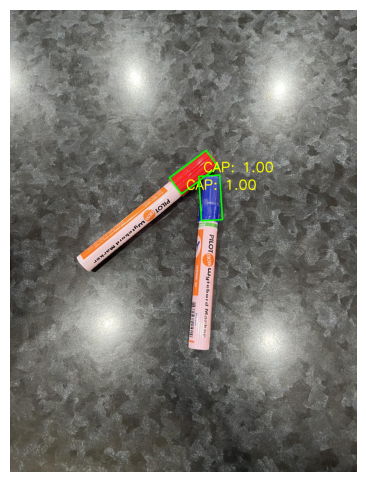

In [ ]:
import cv2
import matplotlib.pyplot as plt
import torch
import numpy as np
import os
import random

# Class labels
CLASS_LABELS = ["CAP"]

PRED_COLORS = {0: (0, 255, 0)}

def draw_rotated_bbox(img, rotated_bbox, label, score, color=(0, 0, 255), thickness=5):
    # rotated_bbox is [x_ctr, y_ctr, w, h, angle]
    x_ctr, y_ctr, w, h, angle = rotated_bbox

    # Calculate the 4 corners of the rotated box
    # angle is in radians in MMRotate 1.x (le90/oc format)
    rect = ((x_ctr, y_ctr), (w, h), np.degrees(angle))
    box = cv2.boxPoints(rect)
    box = np.intp(box)

    # Draw the rotated box
    cv2.drawContours(img, [box], 0, color, thickness)

    # Put label text near the first corner
    cv2.putText(
        img, f"{label}: {score:.2f}", (int(box[0][0]) + 20, int(box[0][1]) - 20),
        cv2.FONT_HERSHEY_SIMPLEX, 2.0, (0, 255, 255), 4, cv2.LINE_AA
    )

# Access the prediction results
pred_instances = result.pred_instances.cpu()

CONF_THRESHOLD = 0.5

# Load the image pixels (img variable is the path)
img_data = cv2.imread(img)
img_with_results = img_data.copy()

# Draw boxes and labels
for i in range(len(pred_instances.bboxes)):
    score = pred_instances.scores[i].item()
    if score < CONF_THRESHOLD:
        continue

    # Get Class and Color
    label_id = pred_instances.labels[i].item()

    class_name = CLASS_LABELS[label_id]
    color = PRED_COLORS[label_id]

    # Extract rotated bbox [x_ctr, y_ctr, w, h, angle]
    rotated_bbox = pred_instances.bboxes[i].tolist()

    # Draw Rotated Bounding Box
    draw_rotated_bbox(img_with_results, rotated_bbox, class_name, score, color=color)

# Show result
img_rgb = cv2.cvtColor(img_with_results, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(6, 6))
plt.axis('off')
plt.imshow(img_rgb)
plt.show()

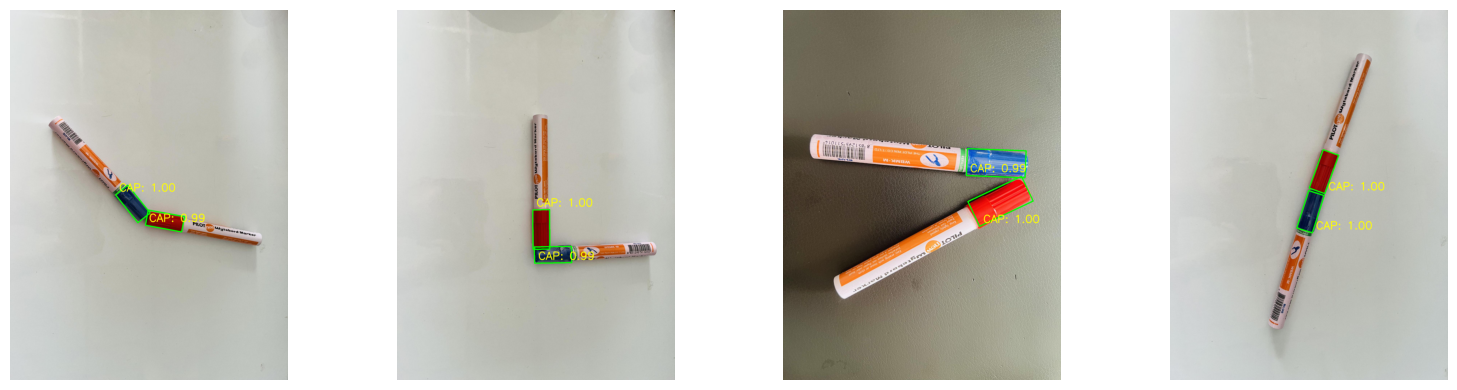

In [ ]:
# ---------------- CONFIG ----------------
val_dir = "/content/gdrive/MyDrive/Pytorch-Models/datasets/markerpensobb/valid/images/"

# visualization layout
N = 4
cols = 4
rows = int(np.ceil(N / cols))

# random image selection
all_imgs = [os.path.join(val_dir, f)
            for f in os.listdir(val_dir)
            if f.lower().endswith((".jpg", ".png", ".jpeg"))]

sample_imgs = random.sample(all_imgs, N)

plt.figure(figsize=(4 * cols, 4 * rows))

for ii, image in enumerate(sample_imgs):
    plt.subplot(1, 4, ii+1)

    img = cv2.imread(image)

    results = inference_detector(model, image)

    pred_instances = results.pred_instances.cpu()

    CONF_THRESHOLD = 0.5
    img_with_results = img.copy()

    # Draw boxes and labels
    for i in range(len(pred_instances.bboxes)):
        score = pred_instances.scores[i].item()
        if score < CONF_THRESHOLD:
            continue

        # Get Class and Color
        label_id = pred_instances.labels[i].item()

        class_name = CLASS_LABELS[label_id]
        color = PRED_COLORS[label_id]

        # Extract rotated bbox [x_ctr, y_ctr, w, h, angle]
        rotated_bbox = pred_instances.bboxes[i].tolist()

        # Draw Rotated Bounding Box
        draw_rotated_bbox(img_with_results, rotated_bbox, class_name, score, color=color)

    plt.subplot(rows, cols, ii + 1)
    plt.imshow(cv2.cvtColor(img_with_results, cv2.COLOR_BGR2RGB))
    plt.axis("off")

plt.tight_layout()
plt.show()